In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import ase
import abtem
from pathlib import Path
import matplotlib.pyplot as plt
import os
import torch
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
from PIL import Image

GPU_use = 0

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"  # con1sistent GPU ordering
os.environ["CUDA_VISIBLE_DEVICES"] = str(GPU_use)
os.environ["OMP_NUM_THREADS"] = "1"

import cupy as cp

In [3]:
# !wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
# wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_l_0b3195.pth
# wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

# Building ABTEM Potentials and Zooming/Cropping into ROIs
*Cedric Lim, 10/28/25*

- Each gold nanoparticle is rotated at different orientatons, and embedded at different z-heights into the carbon substrate.

In [4]:
# Loading ASE atoms

system = ase.io.read('../data/au_np_system.xyz')

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x [Å]', ylabel='z [Å]'>)

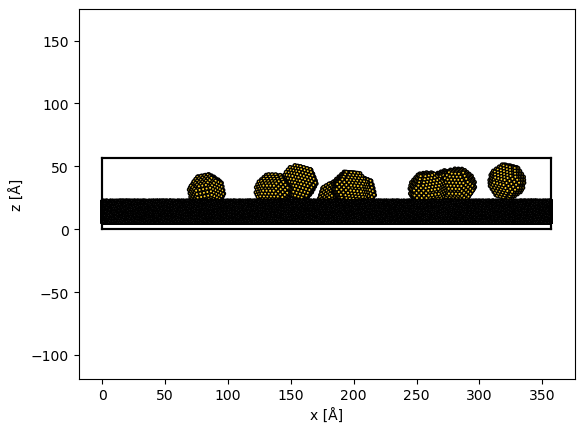

In [5]:
abtem.show_atoms(system, scale = 1, plane = 'xz')

# Building Potentials

In [6]:
potential?

Object `potential` not found.


[########################################] | 100% Completed | 836.15 ms
1836.9126


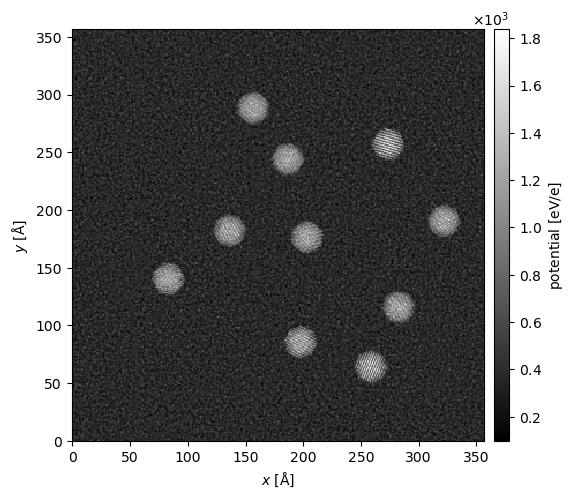

In [7]:
# Multislice simulation to build potential

potential = abtem.Potential(
    system,
    sampling = 1,
    projection = 'infinite',
    slice_thickness = 1,
    # gpts = [100,100],
    device = 'gpu'
).build()

potential.show(cbar = True, cmap = 'gray')
print(potential.array.sum(axis=0).max().compute())
potential_normalized = potential.array/potential.array.sum(axis=0).max().compute() * 255  # Normalize to 0-255
proj_potential_normalized = potential_normalized.sum(axis=0).compute().get()

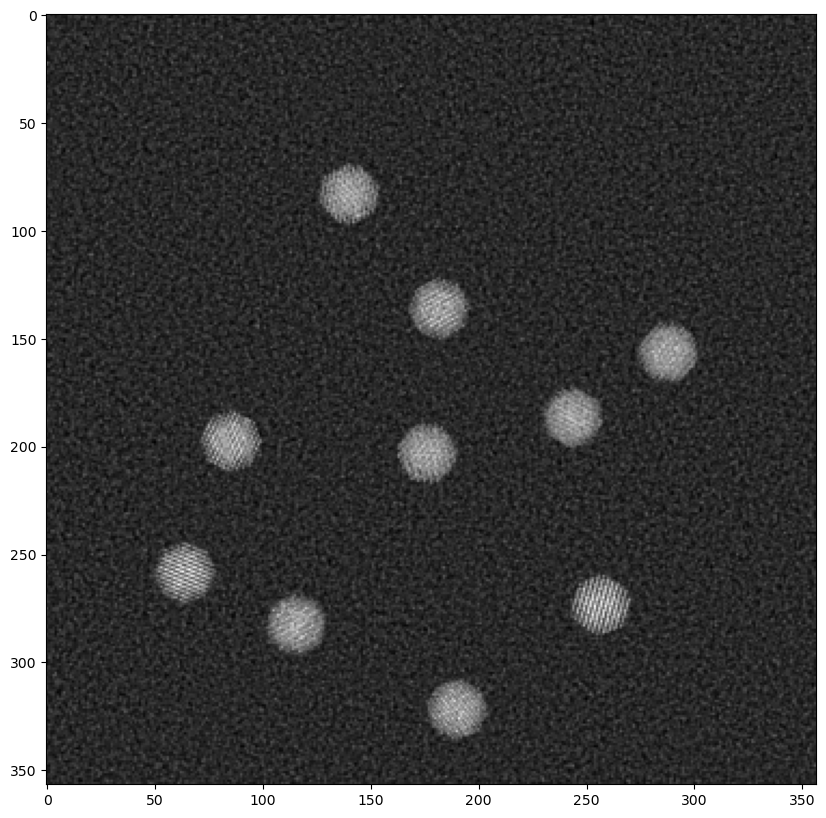

In [8]:
fig, ax = plt.subplots(figsize = (15, 10))
proj_pot = potential.array.sum(axis = 0).compute().get()
# ax.imshow(proj_pot, cmap = 'gray')
ax.imshow(proj_potential_normalized, cmap = 'gray')

# Probe & Defocus

Image shape: (357, 357, 3)
Image dtype: uint8
Image range: [0, 255]


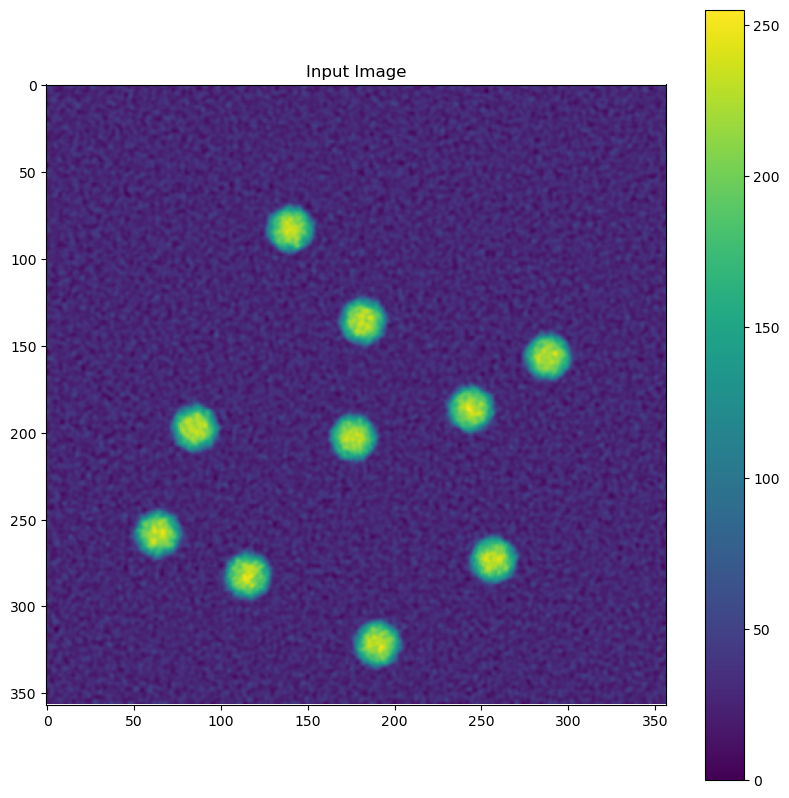

Generating masks...
Error in mask generation: index 2 is out of bounds for dimension 1 with size 0
SAM failed to generate masks. Using simple thresholding.


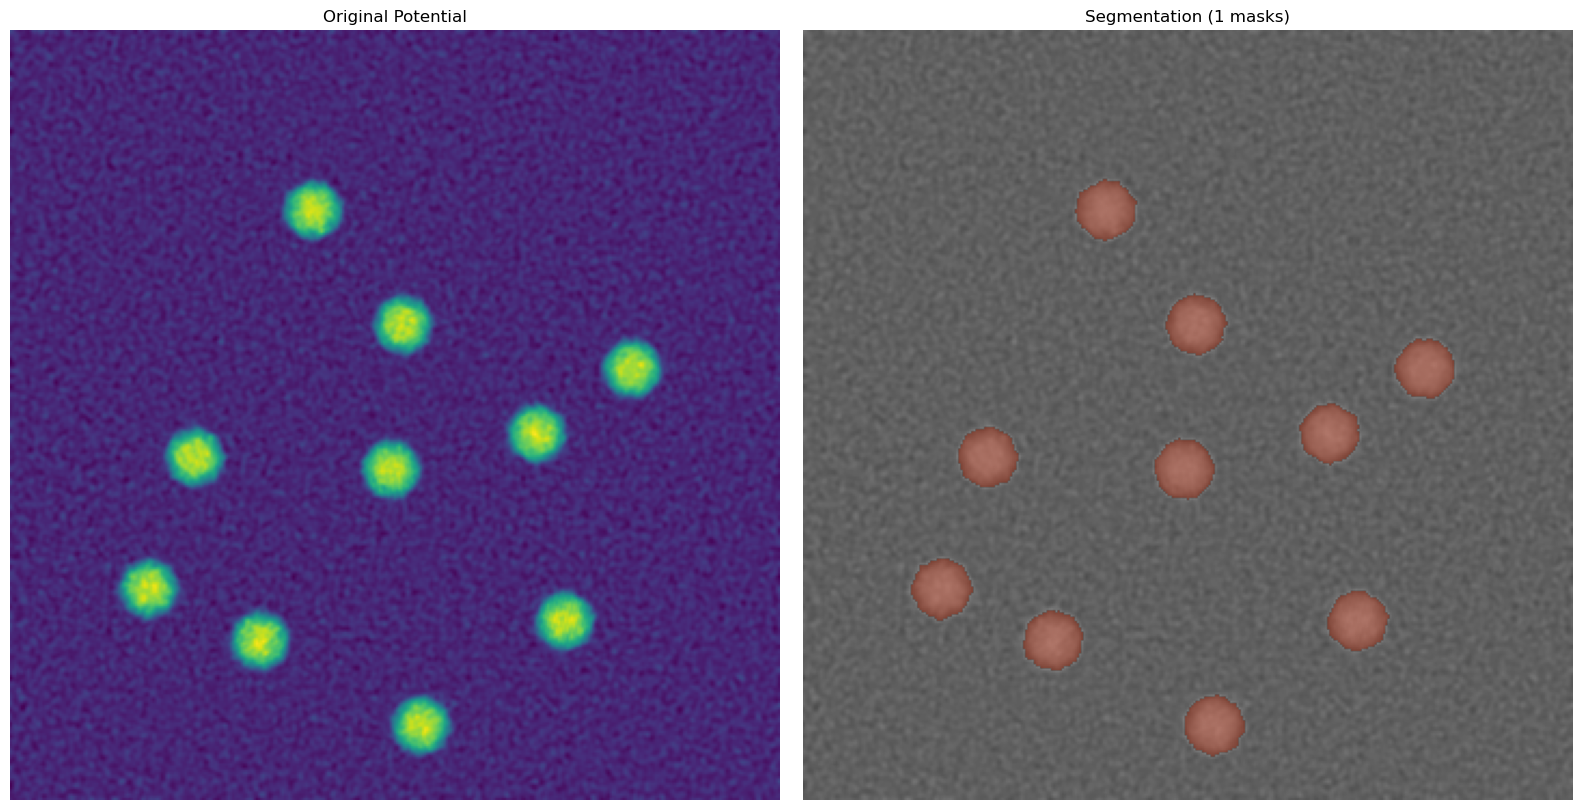

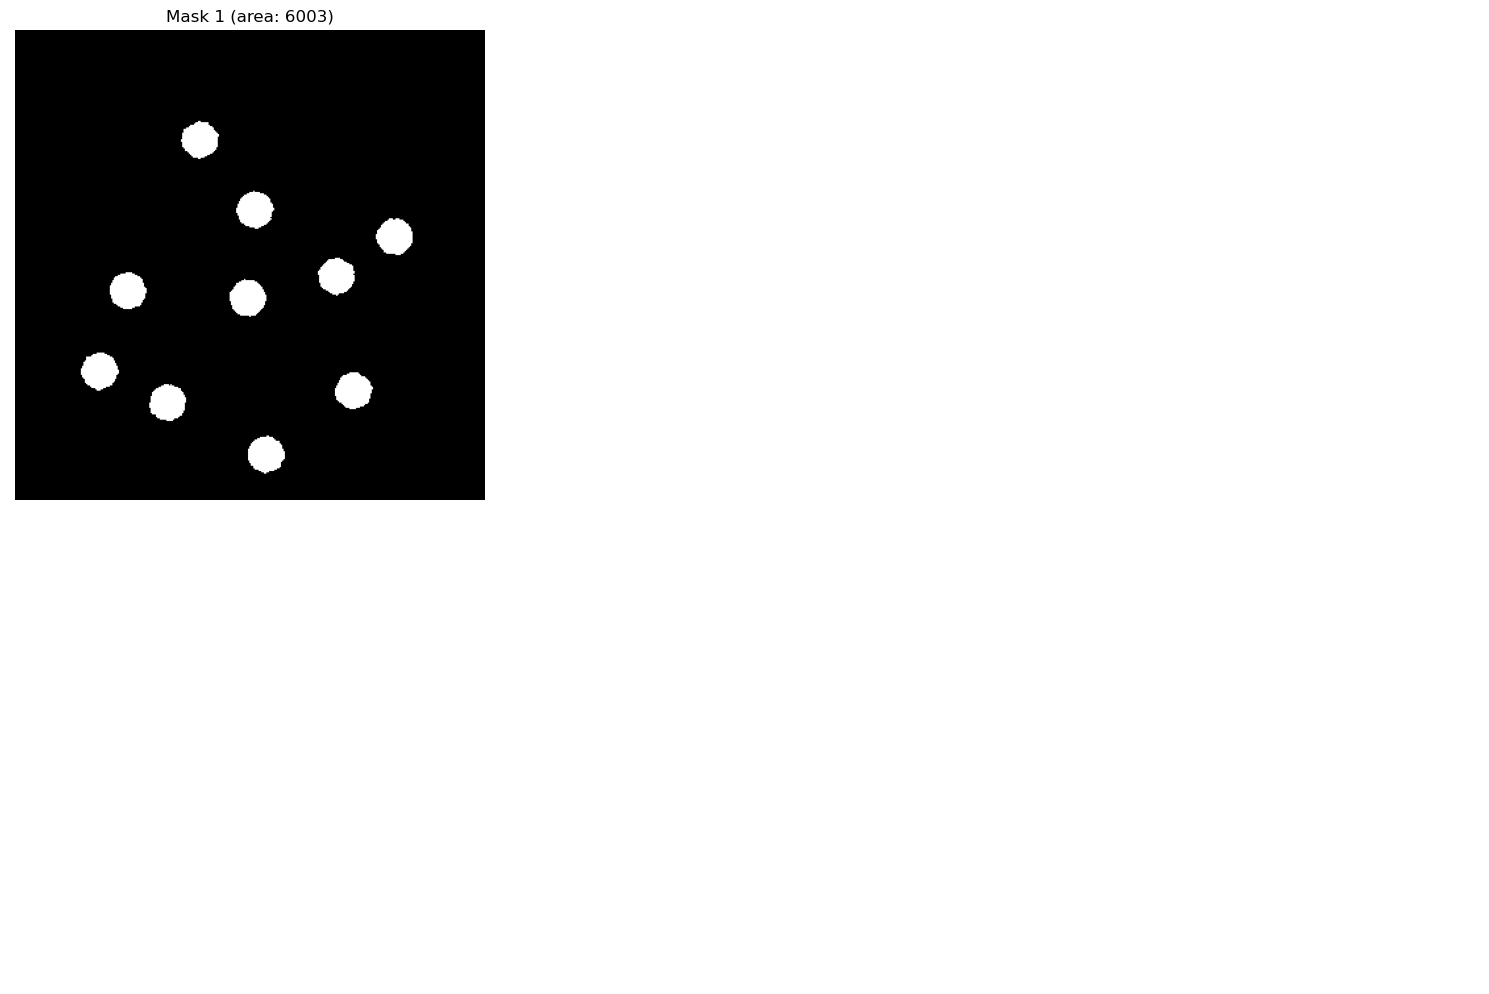

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import skimage.filters as filters
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

# Assuming potential_normalized is your original image
potential_normalized = proj_potential_normalized
# Apply Gaussian smoothing
potential_normalized = filters.gaussian(potential_normalized, sigma=1)
# Enhance contrast
potential_enhanced = (potential_normalized - potential_normalized.min()) / (potential_normalized.max() - potential_normalized.min())
potential_enhanced = (potential_enhanced * 255).astype(np.uint8)

# Convert to 3-channel image (SAM expects RGB)
potential_rgb = np.stack([potential_enhanced] * 3, axis=-1)

print(f"Image shape: {potential_rgb.shape}")
print(f"Image dtype: {potential_rgb.dtype}")
print(f"Image range: [{potential_rgb.min()}, {potential_rgb.max()}]")

# Visualize the input image
plt.figure(figsize=(10, 10))
plt.imshow(potential_rgb[:,:,0], cmap='viridis')
plt.title('Input Image')
plt.colorbar()
plt.show()

# Load SAM model
model_type = "vit_b"
device = "cuda" if torch.cuda.is_available() else "cpu"
sam = sam_model_registry[model_type](checkpoint=None)
sam.to(device=device)

# Create mask generator with adjusted parameters
mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=32,
    pred_iou_thresh=0.90,  # Lowered threshold
    stability_score_thresh=0.85,  # Lowered threshold
    crop_n_layers=1,
    crop_n_points_downscale_factor=2,
    min_mask_region_area=50, 
    output_mode='binary_mask'
)

# Generate masks
print("Generating masks...")
try:
    masks = mask_generator.generate(potential_rgb)
    print(f"Found {len(masks)} segments")
except Exception as e:
    print(f"Error in mask generation: {e}")
    masks = []

# If SAM fails, use simple thresholding
if len(masks) == 0:
    print("SAM failed to generate masks. Using simple thresholding.")
    # Simple thresholding without skimage
    threshold = np.mean(potential_enhanced) + np.std(potential_enhanced)
    binary_mask = potential_enhanced > threshold
    masks = [{'segmentation': binary_mask, 'area': np.sum(binary_mask)}]

def show_masks(image, masks):
    if len(masks) == 0:
        print("No masks found!")
        return
    
    sorted_masks = sorted(masks, key=lambda x: x['area'], reverse=True)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    axes[0].imshow(image[:, :, 0], cmap='viridis')
    axes[0].set_title('Original Potential')
    axes[0].axis('off')
    
    axes[1].imshow(image[:, :, 0], cmap='gray', alpha=0.7)
    
    overlay = np.zeros((*image.shape[:2], 4))
    for i, mask_data in enumerate(sorted_masks):
        mask = mask_data['segmentation']
        color = np.concatenate([np.random.random(3), [0.6]])
        overlay[mask] = color
    
    axes[1].imshow(overlay)
    axes[1].set_title(f'Segmentation ({len(masks)} masks)')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

show_masks(potential_rgb, masks)

# Show individual largest masks (up to 6)
num_masks = min(6, len(masks))
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

sorted_masks = sorted(masks, key=lambda x: x['area'], reverse=True)

for idx, (ax, mask_data) in enumerate(zip(axes, sorted_masks[:num_masks])):
    ax.imshow(mask_data['segmentation'], cmap='gray')
    ax.set_title(f"Mask {idx+1} (area: {mask_data['area']})")
    ax.axis('off')

for idx in range(num_masks, 6):
    axes[idx].axis('off')
    
plt.tight_layout()
plt.show()

Number of labeled features: 10
Number of features after filtering: 10


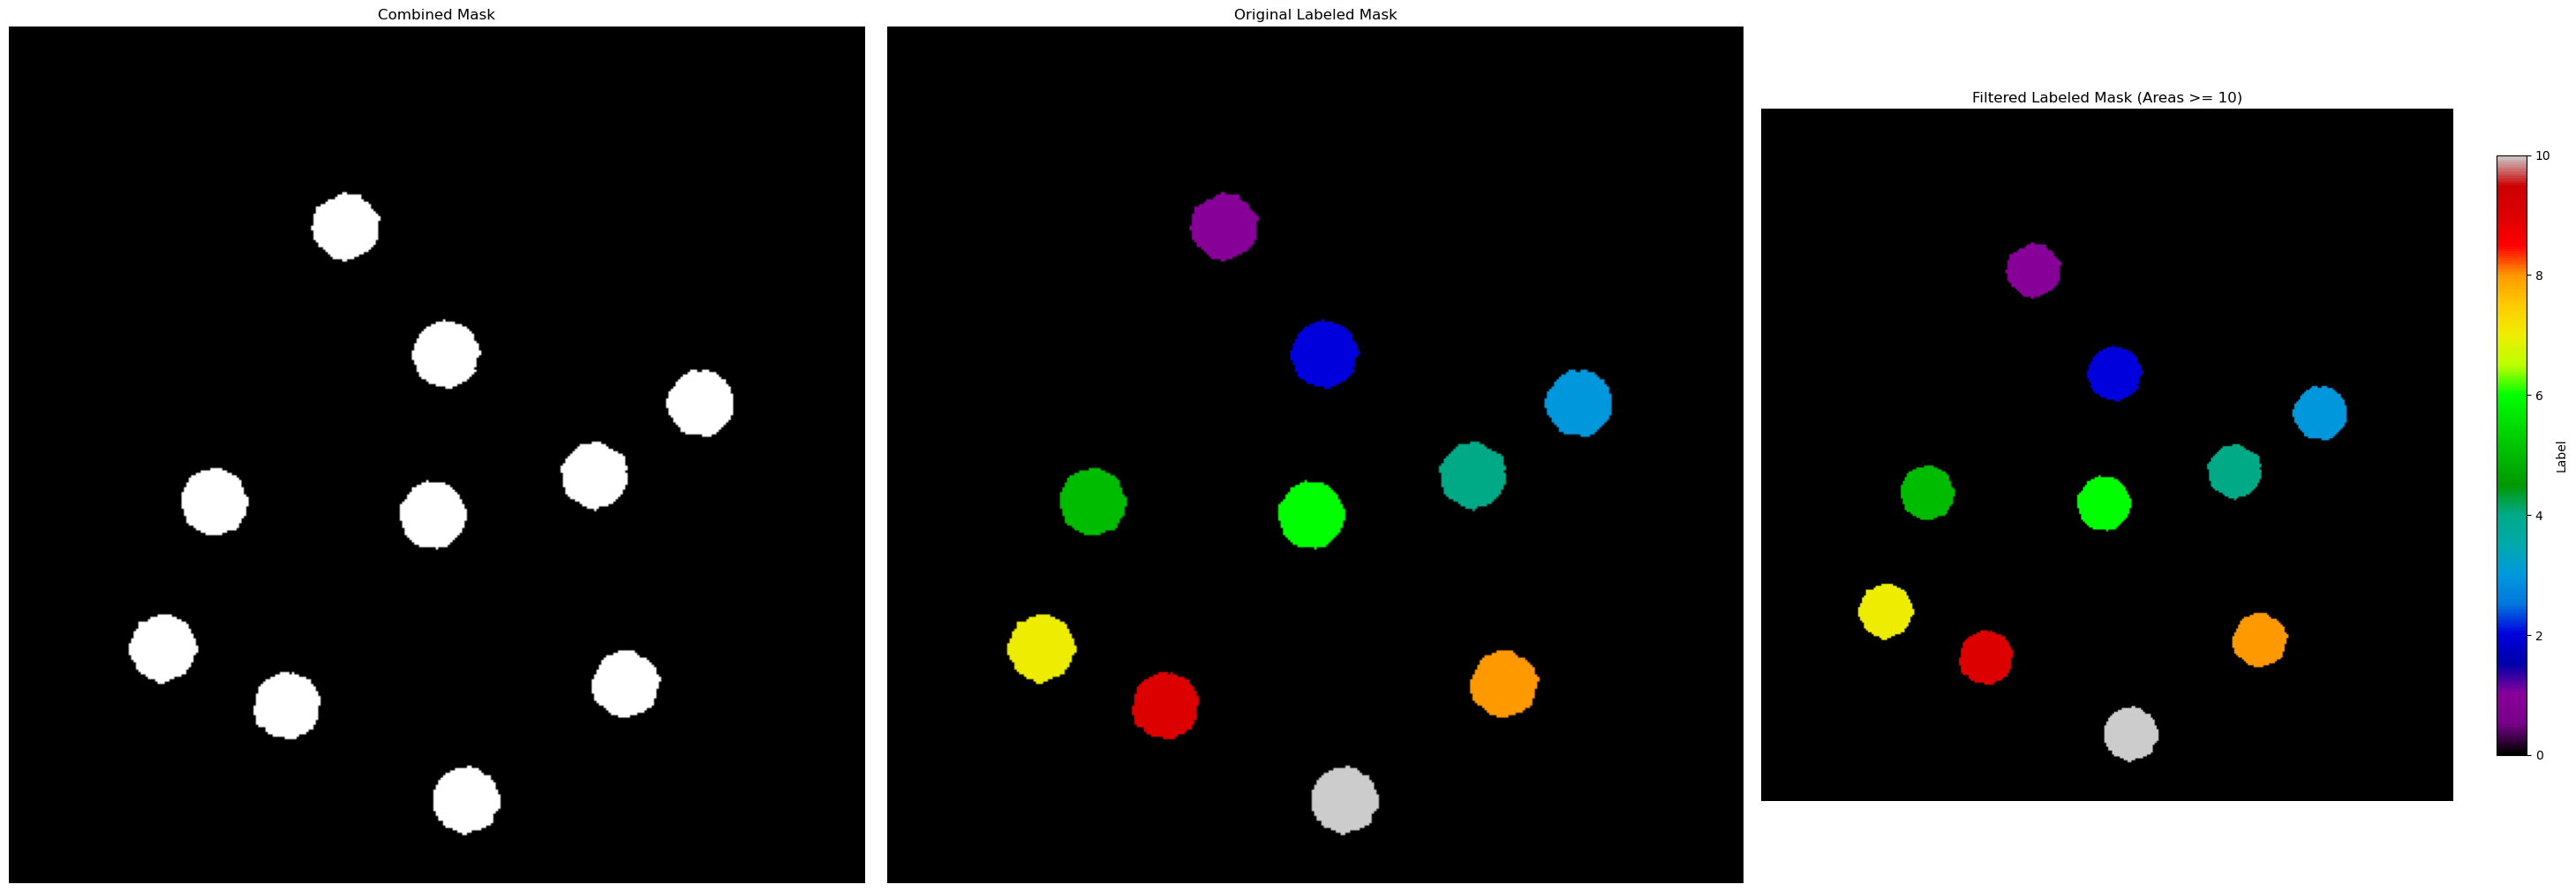

Filtered labeled mask shape: (357, 357)
Unique labels: [ 0  1  2  3  4  5  6  7  8  9 10]
Label: 1
  Area: 598.0
  Centroid: (82.97324414715719, 140.02341137123747)
  Bounding box: (69, 126, 98, 155)
---
Label: 2
  Area: 602.0
  Centroid: (136.1295681063123, 181.79900332225913)
  Bounding box: (122, 168, 151, 197)
---
Label: 3
  Area: 597.0
  Centroid: (156.49916247906197, 287.96817420435514)
  Bounding box: (143, 274, 171, 302)
---
Label: 4
  Area: 592.0
  Centroid: (186.5793918918919, 243.77871621621622)
  Bounding box: (173, 230, 202, 258)
---
Label: 5
  Area: 604.0
  Centroid: (197.62417218543047, 85.24172185430463)
  Bounding box: (184, 72, 212, 100)
---
Label: 6
  Area: 601.0
  Centroid: (203.12811980033277, 176.33943427620633)
  Bounding box: (189, 163, 218, 191)
---
Label: 7
  Area: 606.0
  Centroid: (258.5693069306931, 63.82838283828383)
  Bounding box: (245, 50, 274, 79)
---
Label: 8
  Area: 601.0
  Centroid: (273.53910149750413, 256.69384359401)
  Bounding box: (260, 243, 28

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

def label_and_filter_masks(masks, min_area=100):
    def combine_masks(masks):
        if not masks:
            return None
        combined = np.zeros_like(masks[0]['segmentation'], dtype=bool)
        for mask in masks:
            combined |= mask['segmentation']
        return combined

    def label_mask(mask):
        binary_mask = mask.astype(bool)
        labeled_mask = measure.label(binary_mask, connectivity=2)
        num_features = labeled_mask.max()
        print(f"Number of labeled features: {num_features}")
        return labeled_mask

    def remove_small_labels(labeled_mask, min_area):
        props = measure.regionprops(labeled_mask)
        filtered_mask = np.zeros_like(labeled_mask)
        for prop in props:
            if prop.area >= min_area:
                filtered_mask[labeled_mask == prop.label] = prop.label
        new_labeled_mask = measure.label(filtered_mask > 0)
        num_features = new_labeled_mask.max()
        print(f"Number of features after filtering: {num_features}")
        return new_labeled_mask

    # Combine all masks
    combined_mask = combine_masks(masks)

    if combined_mask is not None:
        # Label the combined mask
        labeled_mask = label_mask(combined_mask)

        # Remove small labels
        filtered_labeled_mask = remove_small_labels(labeled_mask, min_area)

        # Visualize
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(30, 10))

        ax1.imshow(combined_mask, cmap='gray')
        ax1.set_title('Combined Mask')
        ax1.axis('off')

        ax2.imshow(labeled_mask, cmap='nipy_spectral')
        ax2.set_title('Original Labeled Mask')
        ax2.axis('off')

        im = ax3.imshow(filtered_labeled_mask, cmap='nipy_spectral')
        ax3.set_title(f'Filtered Labeled Mask (Areas >= {min_area})')
        ax3.axis('off')

        # Add colorbar
        cbar = fig.colorbar(im, ax=ax3, shrink=0.7)
        cbar.set_label('Label')

        plt.tight_layout()
        plt.show()

        return filtered_labeled_mask
    else:
        print("No masks found!")
        return None

# Assuming 'masks' is your list of mask dictionaries from SAM
min_area = 10  # Adjust this value as needed
filtered_labeled_mask = label_and_filter_masks(masks, min_area)

if filtered_labeled_mask is not None:
    # You can now use filtered_labeled_mask for further analysis
    print("Filtered labeled mask shape:", filtered_labeled_mask.shape)
    print("Unique labels:", np.unique(filtered_labeled_mask))

    # Example: Get properties of the remaining regions
    props = measure.regionprops(filtered_labeled_mask)
    for prop in props:
        print(f"Label: {prop.label}")
        print(f"  Area: {prop.area}")
        print(f"  Centroid: {prop.centroid}")
        print(f"  Bounding box: {prop.bbox}")
        print("---")

In [ ]:

# Automatic download and loading
model_type = "vit_h_lm"  # Light microscopy trained
device = "cuda" if torch.cuda.is_available() else "cpu"

# This automatically downloads and caches the checkpoint
predictor = get_sam_model(
    model_type=model_type,
    device=device
)

# Get automatic mask generator
mask_generator = get_amg(
    predictor=predictor,
    points_per_side=64,
    pred_iou_thresh=0.80,
    stability_score_thresh=0.85,
    min_mask_region_area=50,
)

# Convert grayscale to RGB
if proj_pot.ndim == 2:
    image_rgb = np.stack([proj_pot, proj_pot, proj_pot], axis=-1)
else:
    image_rgb = proj_pot

# Generate masks
print("Generating masks...")
masks = mask_generator.generate(image_rgb)
print(f"✓ Generated {len(masks)} masks")

# Load the model
sam = sam_model_registry[sam_type](checkpoint=checkpoint_path)
sam.to(device=device)
print(f"✓ Loaded EM-trained SAM on {device}")

# Load your grayscale microscopy image
# Assuming you already have 'image_data' loaded
# If not: image_data = cv2.imread('your_image.tif', cv2.IMREAD_GRAYSCALE)



# Convert grayscale to RGB (SAM requires 3 channels)
if proj_pot.ndim == 2:
    # Stack grayscale to create RGB
    image_rgb = np.stack([proj_pot, proj_pot, proj_pot], axis=-1)
elif proj_pot.ndim == 3 and proj_pot.shape[2] == 1:
    # If shape is (H, W, 1), repeat to (H, W, 3)
    image_rgb = np.repeat(proj_pot, 3, axis=2)
else:
    # Already RGB
    image_rgb = proj_pot

# Create mask generator with microscopy-optimized settings
mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=64,           # Increase for more detail
    pred_iou_thresh=0.80,         # Lower to detect more instances
    stability_score_thresh=0.85,  # Lower for less strict stability requirement
    crop_n_layers=1,
    crop_n_points_downscale_factor=1,
    min_mask_region_area=50,      # Lower to detect smaller objects
)

# Generate masks
print("Generating masks...")
masks = mask_generator.generate(image_rgb)
print(f"✓ Generated {len(masks)} masks")

# Visualize results
def show_masks(image, masks, figsize=(15, 7)):
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Original image
    axes[0].imshow(image, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    # Segmentation overlay
    axes[1].imshow(image, cmap='gray')
    
    # Sort masks by area (largest first)
    sorted_masks = sorted(masks, key=lambda x: x['area'], reverse=True)
    
    # Create colored overlay
    for i, mask_data in enumerate(sorted_masks):
        mask = mask_data['segmentation']
        color = np.random.random(3)
        
        # Create colored mask
        colored_mask = np.zeros((*mask.shape, 4))
        colored_mask[mask] = [*color, 0.5]  # 50% transparency
        
        axes[1].imshow(colored_mask)
    
    axes[1].set_title(f'Segmentation ({len(masks)} instances)')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

show_masks(proj_pot, masks)

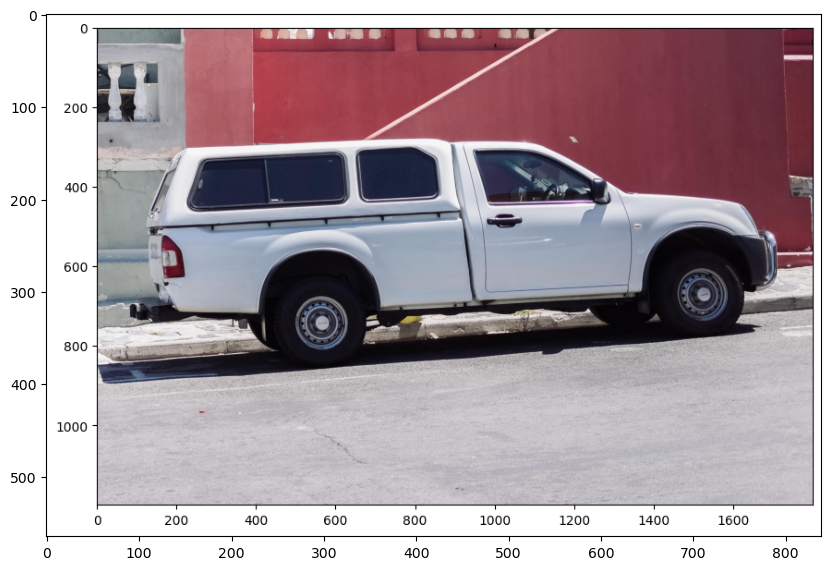

In [50]:
checkpoint = "../sam2/checkpoints/sam2.1_hiera_large.pt"
model_cfg = "../sam2/configs/sam2.1/sam2.1_hiera_l.yaml"
predictor = SAM2ImagePredictor(build_sam2(model_cfg, checkpoint))

image = Image.open('../data/truck1.png')
image = np.array(image.convert("RGB"))
plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis('on')
plt.show()


In [ ]:
# Convert grayscale to 3-channel
if len(proj_pot.shape) == 2:
    proj_pot_3channel = np.stack([proj_pot] * 3, axis=-1)
else:
    proj_pot_3channel = proj_pot

plt.matshow(proj_pot_3channel[:, :, 2])


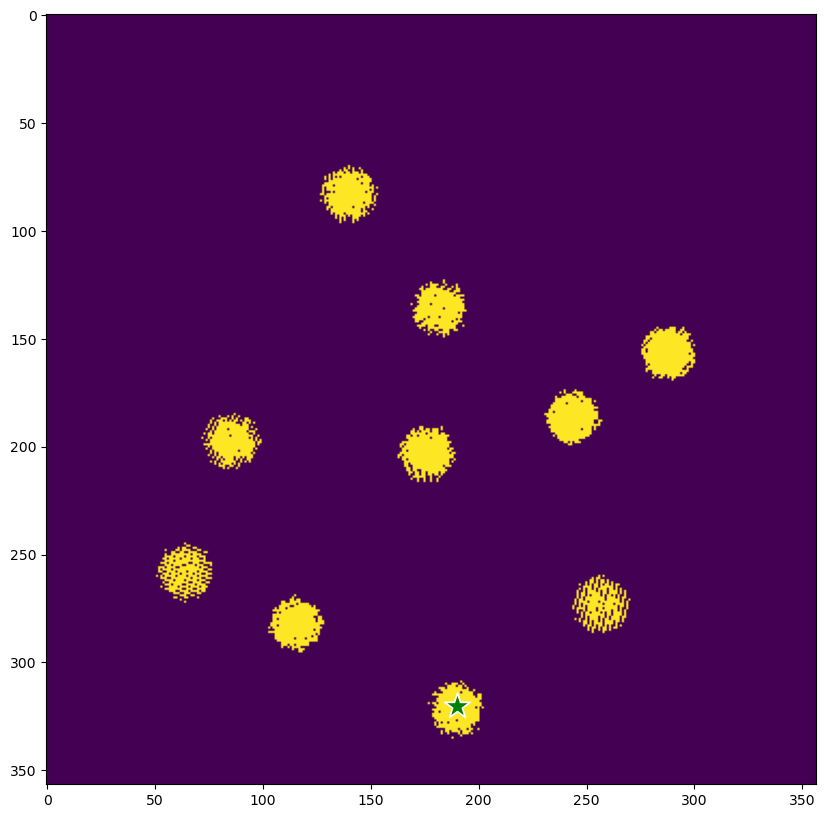

In [65]:
# input_point = np.array([[190, 300]])
input_point = np.array([[190, 320]])
input_label = np.array([1])
plt.figure(figsize=(10, 10))
# plt.imshow(image)
plt.imshow(proj_pot>(0.45*np.max(proj_pot)))
show_points(input_point, input_label, plt.gca())
plt.axis('on')
plt.show()  

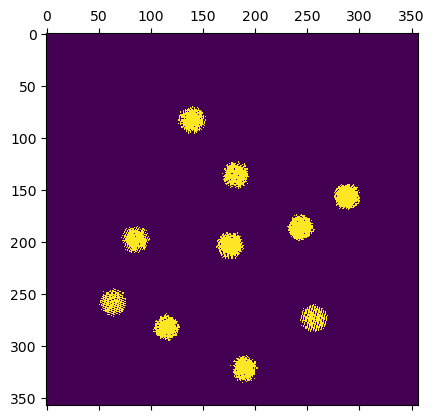

In [72]:
if len(proj_pot.shape) == 2:
    proj_pot_3channel = np.stack([(proj_pot>(0.45*np.max(proj_pot))).astype(np.float32)] * 3, axis=-1)
else:
    proj_pot_3channel = proj_pot>(0.45*np.max(proj_pot))

plt.matshow(proj_pot_3channel[:, :, 2])

In [75]:
predictor.set_image(proj_pot_3channel)
masks, scores, _ = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=False,
)
masks, scores, _ = predictor.predict(
)

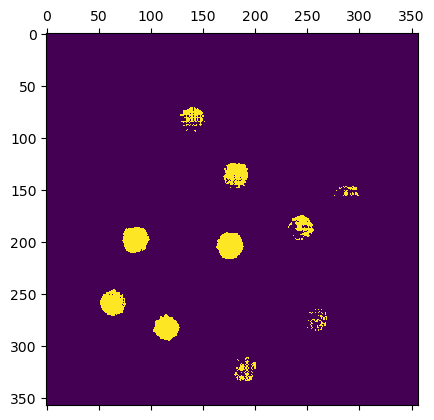

In [76]:
plt.matshow(masks[0])

In [ ]:
with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
    predictor.set_image(proj_pot_3channel)
    masks, scores, logits = predictor.predict()


# with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
#     predictor.set_image(proj_pot)
#     masks = predictor.generate()
#     # masks, _, _ = predictor.predict(
        
#     # )
#     for i, mask in enumerate(masks):
#         # Convert the mask to a binary image
#         binary_mask = mask.astype(np.uint8) * 255
#         plt.matshow(binary_mask)

In [21]:
probe = abtem.Probe(energy=300e3, 
                    semiangle_cutoff=50, 
                    defocus = 0,
                    extent = 100,
                    gpts = [64,64],
                    device = "gpu")
probe.grid.match(potential)

[########################################] | 100% Completed | 202.79 ms


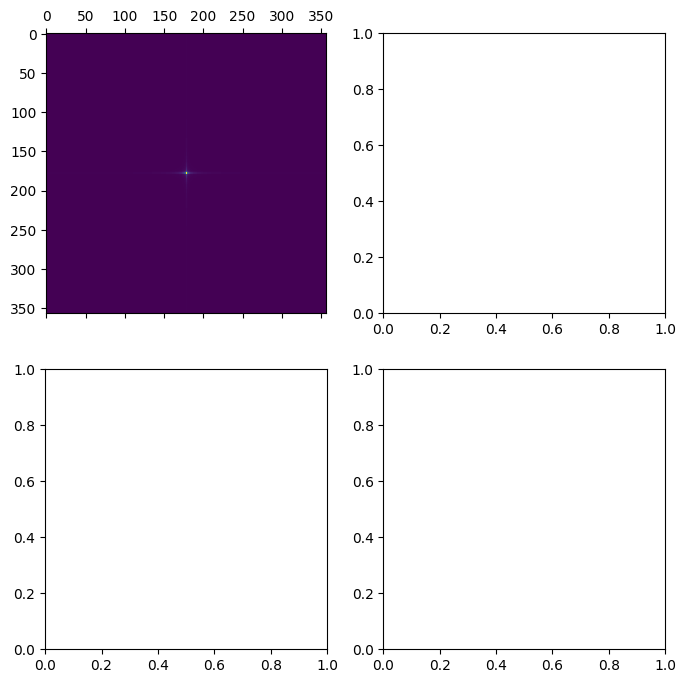

In [22]:
prb = probe.build().compute().array
fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(8, 8))
crop = 80
axs[0,0].matshow(np.abs(prb.get()))
# axs[0,0].set_title('full fov probe abs')
# axs[0,1].matshow(np.abs(prb)[crop:-crop, crop:-crop])
# axs[0,1].set_title('zoom view of probe')
# axs[1,0].plot(np.abs(prb)[:, prb.shape[1]//2][crop:-crop])
# axs[1,0].set_title('cross section of probe intensity')
# axs[1,1].plot(np.real(prb)[:, prb.shape[1]//2][crop:-crop])
# axs[1,1].set_title('cross section of probe real component')

In [36]:
from abtem.detectors import AnnularDetector

detector_haadf = AnnularDetector(
    inner=50e-3,  # 50 mrad
    outer=200e-3, # 200 mrad
)

grid_scan = abtem.GridScan(
    start = [100,50],
    end = [150,100],
    gpts = [100,100],
)

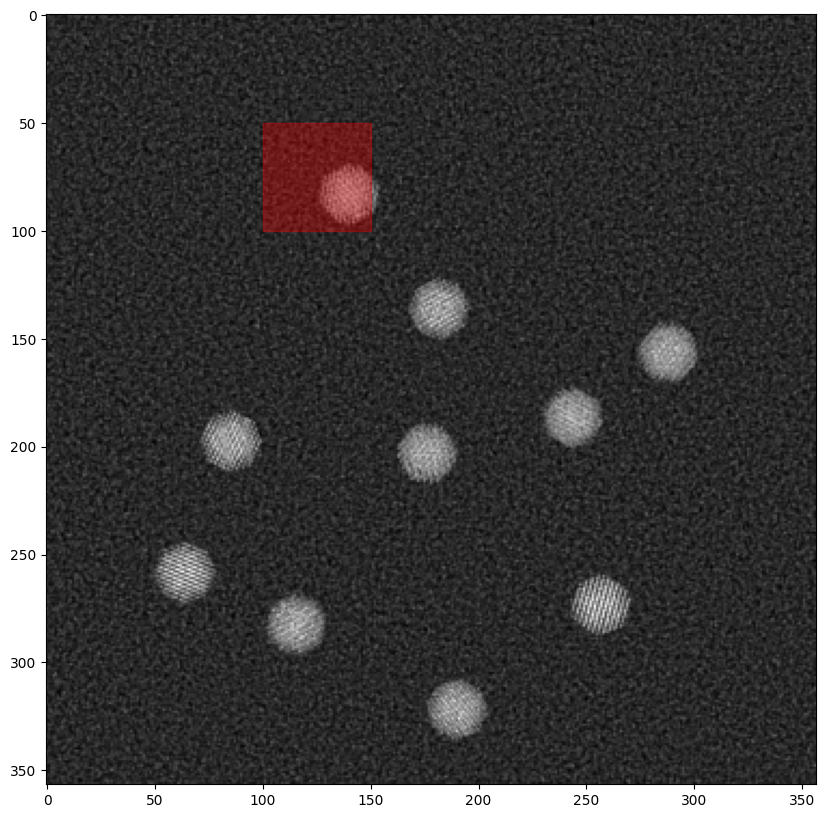

In [37]:
fig, ax = plt.subplots(figsize = (15, 10))
proj_pot = potential.array.sum(axis = 0).compute().get()
ax.imshow(proj_pot, cmap = 'gray')
grid_scan.add_to_plot(ax)

In [38]:
measurements = probe.scan(potential, scan = grid_scan, detectors=[detector_haadf])

# measurements.show(explode = True, cbar = True)

[########################################] | 100% Completed | 16.31 ss


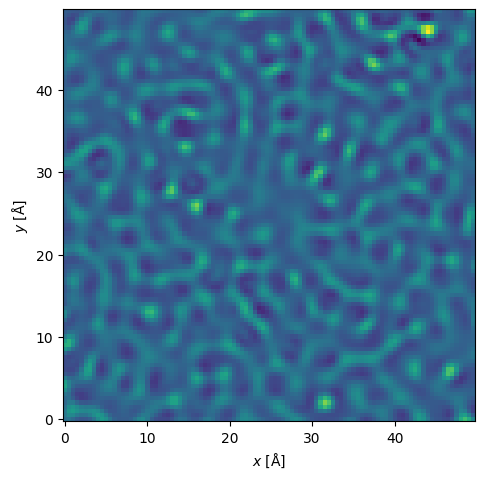

In [39]:
measurements.show()

# Segmentation